# ECAPA-TDNN Speaker Verification on Vietnam-Celeb (E / H)

This notebook evaluates a **pretrained** ECAPA-TDNN (SpeechBrain `speechbrain/spkrec-ecapa-voxceleb`)
and a **fine-tuned** ECAPA checkpoint on speaker verification trial lists for **Vietnam-Celeb (E / H)**,
using cosine-similarity scoring on embeddings, and reports **EER** and **minDCF**.

This is a split-out version of the combined VoxVietnam + Vietnam-Celeb evaluation notebook,
containing only the Vietnam-Celeb (E / H) portion. The pipeline is written around a single
`evaluate_model(...)` function that takes a *loaded SpeechBrain model object* as input, so
evaluating the fine-tuned checkpoint only requires loading it with `load_finetuned_model(...)`
and re-running the same evaluation call — no other code needs to change. Results from both
runs are appended to the same `results/verification_results.csv` so they can be compared side by side.


## 1. Setup

In [1]:
!pip install -q speechbrain torchaudio soundfile


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 45.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import csv
import time
import json

import numpy as np
import pandas as pd
import torch
import torchaudio
import soundfile as sf

from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

RESULTS_DIR = Path("/kaggle/working/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "verification_results.csv"

EMBED_CACHE_DIR = Path("/kaggle/working/embeddings_cache")
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda


## 2. Config

In [3]:
# --- Vietnam-Celeb ---
CELEB_FULL_AUDIO = Path("/kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data")
CELEB_E_PAIR = Path("/kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/vietnam-celeb-e.txt")
CELEB_H_PAIR = Path("/kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/vietnam-celeb-h.txt")

POSITIVE_LABEL = "1"     # label string meaning "same speaker"
TARGET_SR = 16000        # ECAPA-TDNN (voxceleb) expects 16 kHz mono

# --- Models ---
# Pretrained ECAPA-TDNN from SpeechBrain (downloaded from HF hub, cached under savedir)
PRETRAINED_SOURCE = "speechbrain/spkrec-ecapa-voxceleb"
PRETRAINED_SAVEDIR = "/kaggle/working/pretrained_models/ecapa_pretrained"

# Fine-tuned ECAPA: same base architecture (speechbrain/spkrec-ecapa-voxceleb), but only the
# embedding_model's weights are fine-tuned and shipped as a raw state_dict on the HF Hub (not a
# full SpeechBrain checkpoint dir). We load the base model's other modules (feature extractor,
# mean/var norm) as-is and swap in the fine-tuned embedding_model weights.
FINETUNED_BASE_SOURCE = "speechbrain/spkrec-ecapa-voxceleb"
FINETUNED_SAVEDIR = "/kaggle/working/pretrained_models/ecapa_finetuned"
FINETUNED_HF_REPO_ID = "Nampfiev1995/pvad-speechbrain-ft"
FINETUNED_HF_FILENAME = "best_checkpoint_rec98.pt"


## 3. Load a SpeechBrain ECAPA model (reusable for pretrained & fine-tuned)

Two loaders, both returning the same kind of `SpeakerRecognition` object so the rest of the notebook
(`encode_batch`, caching, scoring, metrics) doesn't care which one it's holding:

- `load_pretrained_model()` — loads `speechbrain/spkrec-ecapa-voxceleb` straight from the hub.
- `load_finetuned_model()` — loads the same base model, then downloads the fine-tuned checkpoint
  (a raw `embedding_model` state_dict, not a full SpeechBrain save dir) from the Hub and swaps it into
  `model.mods.embedding_model`. Everything else (feature extraction, mean/var norm) stays the
  pretrained-base version, matching how the checkpoint was produced.

In [4]:
from speechbrain.inference.speaker import SpeakerRecognition
from huggingface_hub import hf_hub_download


def load_pretrained_model(source: str = PRETRAINED_SOURCE, savedir: str = PRETRAINED_SAVEDIR,
                           device: str = DEVICE):
    """Load the stock SpeechBrain ECAPA-TDNN (speechbrain/spkrec-ecapa-voxceleb)."""
    model = SpeakerRecognition.from_hparams(
        source=source,
        savedir=savedir,
        run_opts={"device": device},
    )
    model.eval()
    return model


def load_finetuned_model(base_source: str = FINETUNED_BASE_SOURCE, savedir: str = FINETUNED_SAVEDIR,
                          hf_repo_id: str = FINETUNED_HF_REPO_ID, hf_filename: str = FINETUNED_HF_FILENAME,
                          device: str = DEVICE):
    """Load the base ECAPA-TDNN, then overwrite embedding_model with fine-tuned weights from the Hub."""
    model = SpeakerRecognition.from_hparams(
        source=base_source,
        savedir=savedir,
        run_opts={"device": device},
    )
    ckpt_path = hf_hub_download(repo_id=hf_repo_id, filename=hf_filename)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.mods.embedding_model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


pretrained_model = load_pretrained_model()
print("Pretrained ECAPA-TDNN loaded on", DEVICE)


hyperparams.yaml: 0.00B [00:00, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt: 0.00B [00:00, ?B/s]

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Pretrained ECAPA-TDNN loaded on cuda


## 4. Trial-pair and audio loading utilities

Both trial files list *relative* audio paths (`wav/...` for VoxVietnam, `idXXXXX/....wav` for
Vietnam-Celeb) which are joined with the corresponding audio root. `read_trials` auto-detects the
delimiter (comma vs tab) unless you pass one explicitly.

In [5]:
def read_trials(pair_file: Path, audio_root: Path, delimiter: str = None) -> pd.DataFrame:
    """Parse a trial-pairs file into a DataFrame with columns [label, path1, path2] (absolute paths).

    Handles two on-disk shapes:
      - plain delimited text, e.g. `1\tid00896/00002.wav\tid00896/00001.wav`
      - a real CSV where each line is itself a single quoted field containing the delimiter,
        e.g. `"1\twav/audio00001.wav\twav/audio00002.wav"` (VoxVietnam's test_list_gt.csv).
        In this case the quotes must be stripped BEFORE splitting, otherwise csv's quote handling
        swallows the whole line as one field and produces only 1 column instead of 3.

    Any pair where either audio file doesn't actually exist on disk is dropped (with a summary
    printed), rather than failing later inside embedding extraction. In addition to listing the
    individual missing audio files, this also reports missing *speakers* — i.e. cases where the
    speaker's whole subfolder (the first path component, e.g. `idXXXXX` in `idXXXXX/00001.wav`)
    doesn't exist under `audio_root` at all, rather than just one utterance being absent.
    """
    with open(pair_file, "r", encoding="utf-8") as f:
        raw_lines = [line.rstrip("\n").rstrip("\r") for line in f if line.strip()]

    if delimiter is None:
        probe = raw_lines[0].strip().strip('"')
        delimiter = "\t" if "\t" in probe else ","

    rows = []
    for line in raw_lines:
        line = line.strip()
        # Strip one layer of wrapping quotes if the whole line is quoted (CSV-of-quoted-tsv case).
        if len(line) >= 2 and line[0] == '"' and line[-1] == '"':
            line = line[1:-1]
        parts = [p.strip() for p in line.split(delimiter)]
        if len(parts) < 3:
            continue
        label, p1, p2 = parts[0], parts[1], parts[2]
        rows.append((label, p1, p2, str(audio_root / p1), str(audio_root / p2)))

    df = pd.DataFrame(rows, columns=["label", "rel_path1", "rel_path2", "path1", "path2"])
    df["target"] = (df["label"] == POSITIVE_LABEL).astype(int)

    n_before = len(df)
    exists_mask = df["path1"].apply(lambda p: Path(p).is_file()) & df["path2"].apply(lambda p: Path(p).is_file())
    missing = df.loc[~exists_mask]
    if len(missing) > 0:
        missing_path1 = missing.loc[~missing["path1"].apply(lambda p: Path(p).is_file())]
        missing_path2 = missing.loc[~missing["path2"].apply(lambda p: Path(p).is_file())]
        missing_paths = pd.unique(pd.concat([missing_path1["path1"], missing_path2["path2"]]))

        print(f"[read_trials] WARNING: dropping {len(missing)}/{n_before} pairs "
              f"referencing {len(missing_paths)} missing audio file(s) under {audio_root}")
        for p in missing_paths[:10]:
            print("   missing file:", p)
        if len(missing_paths) > 10:
            print(f"   ... and {len(missing_paths) - 10} more")

        # Missing speakers: the first path component (speaker id, e.g. "idXXXXX") of a missing
        # utterance whose folder isn't present under audio_root at all — distinct from a single
        # missing file inside an otherwise-present speaker folder.
        def speaker_of(rel_path: str) -> str:
            parts = Path(rel_path).parts
            return parts[0] if len(parts) > 1 else ""

        missing_rel_paths = pd.unique(pd.concat([
            missing_path1["rel_path1"],
            missing_path2["rel_path2"],
        ]))
        missing_speakers = sorted({
            spk for spk in (speaker_of(rp) for rp in missing_rel_paths)
            if spk and not (audio_root / spk).is_dir()
        })
        if missing_speakers:
            print(f"[read_trials] WARNING: {len(missing_speakers)} missing speaker folder(s) under {audio_root}")
            for spk in missing_speakers[:10]:
                print("   missing speaker:", spk)
            if len(missing_speakers) > 10:
                print(f"   ... and {len(missing_speakers) - 10} more")

    df = df.loc[exists_mask].reset_index(drop=True)
    df = df.drop(columns=["rel_path1", "rel_path2"])

    return df


def load_waveform(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load an audio file as a mono float32 tensor resampled to target_sr, shape (1, T)."""
    if not Path(path).is_file():
        raise FileNotFoundError(f"Audio file not found: {path}")
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    return wav


## 5. Embedding extraction with on-disk caching

Trial lists reuse the same utterances across many pairs, so we extract each unique file's embedding
once, cache it in memory (and optionally on disk per model), and just look it up for every pair. This
keeps runtime to O(#unique utterances) instead of O(#pairs).

In [6]:
@torch.no_grad()
def extract_embeddings(model, audio_paths, cache: dict, batch_desc: str = "", log_every: int = 500):
    """Fill `cache[path] -> np.ndarray embedding` for every path not already cached.

    Paths that don't exist (or fail to load) are skipped with a warning rather than crashing the
    whole run; `score_trials` will then simply have no cache entry for them, so make sure trials
    were already filtered by `read_trials` (which drops pairs with missing files up front).
    """
    todo = [p for p in audio_paths if p not in cache]
    t0 = time.time()
    n_failed = 0
    for i, path in enumerate(todo):
        if not Path(path).is_file():
            print(f"[extract_embeddings] WARNING: file not found, skipping: {path}")
            n_failed += 1
            continue
        try:
            wav = load_waveform(path).to(DEVICE)
            emb = model.encode_batch(wav)          # shape (1, 1, D)
            emb = emb.squeeze().detach().cpu().numpy()
            emb = emb / (np.linalg.norm(emb) + 1e-8)
            cache[path] = emb
        except Exception as e:
            print(f"[extract_embeddings] WARNING: failed to embed {path}: {e}")
            n_failed += 1
        if log_every and (i + 1) % log_every == 0:
            elapsed = time.time() - t0
            print(f"[{batch_desc}] {i+1}/{len(todo)} embeddings "
                  f"({elapsed:.1f}s, {(i+1)/elapsed:.1f} files/s)")
    if n_failed:
        print(f"[extract_embeddings] {n_failed}/{len(todo)} files skipped due to errors")
    return cache


def score_trials(trials: pd.DataFrame, cache: dict) -> pd.DataFrame:
    """Cosine similarity score for every trial pair whose embeddings are both in cache.

    Returns the (possibly filtered) trials DataFrame with a new 'score' column, so labels and
    scores always stay aligned even if some pairs had to be dropped due to embedding failures.
    """
    has_both = trials["path1"].isin(cache) & trials["path2"].isin(cache)
    n_dropped = int((~has_both).sum())
    if n_dropped:
        print(f"[score_trials] WARNING: dropping {n_dropped}/{len(trials)} pairs missing an embedding")
    trials = trials.loc[has_both].reset_index(drop=True)
    scores = np.empty(len(trials), dtype=np.float64)
    for i, (p1, p2) in enumerate(zip(trials["path1"], trials["path2"])):
        scores[i] = float(np.dot(cache[p1], cache[p2]))
    trials = trials.copy()
    trials["score"] = scores
    return trials


## 6. Metrics: EER and minDCF

- **EER**: threshold where false-accept rate (FAR) equals false-reject rate (FRR).
- **minDCF**: minimum detection cost function, using the standard NIST SRE-style costs
  (`P_target=0.01`, `C_miss=1`, `C_fa=1`), which is the convention most VoxCeleb-family papers report.

In [7]:
def compute_eer(labels: np.ndarray, scores: np.ndarray):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    # index where FPR and FNR cross
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2
    eer_threshold = thresholds[idx]

    print(f"EER: {eer * 100:.2f}%, FAR: {fpr[idx]:.3f}, FRR: {fnr[idx]:.3f} (threshold={eer_threshold:.3f})")
    return float(eer), float(eer_threshold)


def compute_min_dcf(labels: np.ndarray, scores: np.ndarray,
                     p_target: float = 0.01, c_miss: float = 1.0, c_fa: float = 1.0):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    dcf = c_miss * fnr * p_target + c_fa * fpr * (1 - p_target)
    min_idx = np.argmin(dcf)
    dcf_norm = min(c_miss * p_target, c_fa * (1 - p_target))
    min_dcf = dcf[min_idx] / dcf_norm

    print(f"minDCF: {min_dcf:.4f}, FAR: {fpr[min_idx]:.3f}, FRR: {fnr[min_idx]:.3f}  (threshold={thresholds[min_idx]:.3f})")
    return float(min_dcf), float(thresholds[min_idx])


## 7. End-to-end evaluation pipeline

`evaluate_model` does everything for one (model, trial-file) combination: parse trials, extract/cache
embeddings, score pairs, compute EER/minDCF, plot the score distribution, and append a row to the
persistent results CSV. Call it once per (model, dataset) — the same call works for the fine-tuned model
later, just pass a different `model` and `model_name`.

In [8]:
def evaluate_model(model, model_name: str, dataset_name: str,
                    pair_file: Path, audio_root: Path, delimiter: str = None,
                    embed_cache: dict = None, plot: bool = True):
    print(f"\n=== Evaluating '{model_name}' on '{dataset_name}' ===")
    trials = read_trials(pair_file, audio_root, delimiter=delimiter)
    print(f"Loaded {len(trials)} trial pairs "
          f"({trials['target'].sum()} genuine / {(1 - trials['target']).sum()} impostor)")

    unique_paths = pd.unique(pd.concat([trials["path1"], trials["path2"]]))
    print(f"Unique utterances to embed: {len(unique_paths)}")

    if embed_cache is None:
        embed_cache = {}
    extract_embeddings(model, unique_paths, embed_cache, batch_desc=f"{model_name}/{dataset_name}")

    # score_trials drops any pair whose embedding failed/was missing and returns trials+scores
    # aligned, so labels/scores below always correspond to files that were actually loaded.
    scored = score_trials(trials, embed_cache)
    labels = scored["target"].to_numpy()
    scores = scored["score"].to_numpy()

    eer, eer_thr = compute_eer(labels, scores)
    min_dcf, dcf_thr = compute_min_dcf(labels, scores)

    print(f"EER: {eer * 100:.2f}%  (threshold={eer_thr:.3f})")
    print(f"minDCF: {min_dcf:.4f}  (threshold={dcf_thr:.3f})")

    if plot:
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(x=scores[labels == 1], color="tab:green", label="target", stat="density",
                     kde=True, alpha=0.4, ax=ax)
        sns.histplot(x=scores[labels == 0], color="tab:red", label="non-target", stat="density",
                     kde=True, alpha=0.4, ax=ax)
        ax.axvline(eer_thr, color="black", linestyle="--", linewidth=2, label="EER threshold")
        ax.axvline(dcf_thr, color="black", linestyle=":", linewidth=2, label="minDCF threshold")
        ax.set_title(f"{model_name} on {dataset_name}\nEER={eer*100:.2f}%  minDCF={min_dcf:.4f}")
        ax.set_xlabel("cosine similarity score")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Persist raw scores (useful for later DET curves / significance tests across models)
    scores_path = RESULTS_DIR / f"scores_{model_name}_{dataset_name}.csv"
    pd.DataFrame({"label": labels, "score": scores}).to_csv(scores_path, index=False)

    result_row = {
        "model": model_name,
        "dataset": dataset_name,
        "num_trials": len(scored),
        "num_genuine": int(scored["target"].sum()),
        "num_impostor": int((1 - scored["target"]).sum()),
        "eer_pct": eer * 100,
        "min_dcf": min_dcf,
        "scores_file": str(scores_path),
    }

    # Append to the persistent results table (create it if it doesn't exist yet)
    if RESULTS_CSV.exists():
        results_df = pd.read_csv(RESULTS_CSV)
        results_df = results_df[~((results_df["model"] == model_name) & (results_df["dataset"] == dataset_name))]
        results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)
    else:
        results_df = pd.DataFrame([result_row])
    results_df.to_csv(RESULTS_CSV, index=False)

    return result_row, embed_cache


## 8. Run evaluation — Pretrained ECAPA-TDNN

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Pretrained ECAPA-TDNN loaded on cuda

=== Evaluating 'ecapa_pretrained' on 'vietnam_celeb_E' ===
[read_trials] WARNING: dropping 7532/55016 pairs referencing 194 missing audio file(s) under /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00022.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00017.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00014.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00012.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00023.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00020.wav
   missing file: /kaggle/input/datasets/davidth

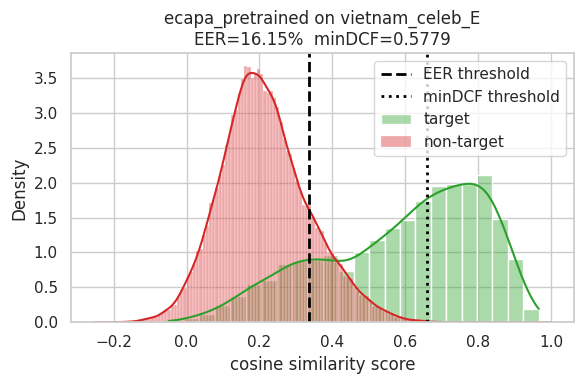


=== Evaluating 'ecapa_pretrained' on 'vietnam_celeb_H' ===
[read_trials] WARNING: dropping 3969/55016 pairs referencing 185 missing audio file(s) under /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00014.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00020.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00016.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00009.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00013.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00005.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-d

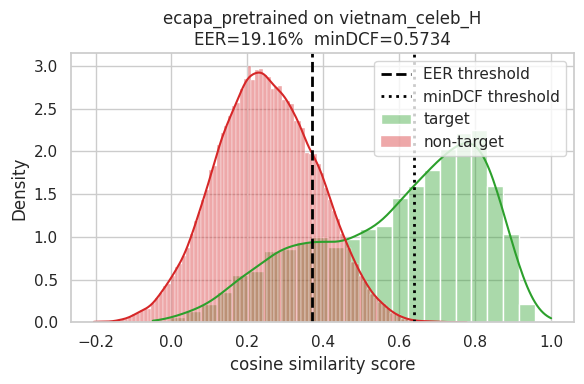

In [9]:
pretrained_model = load_pretrained_model()
print("Pretrained ECAPA-TDNN loaded on", DEVICE)

pretrained_cache = {}

result_celeb_e_pre, pretrained_cache = evaluate_model(
    pretrained_model, "ecapa_pretrained", "vietnam_celeb_E",
    CELEB_E_PAIR, CELEB_FULL_AUDIO, delimiter="\t",
    embed_cache=pretrained_cache,
)

result_celeb_h_pre, pretrained_cache = evaluate_model(
    pretrained_model, "ecapa_pretrained", "vietnam_celeb_H",
    CELEB_H_PAIR, CELEB_FULL_AUDIO, delimiter="\t",
    embed_cache=pretrained_cache,
)


## 9. Run evaluation — Fine-tuned ECAPA-TDNN

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


best_checkpoint_rec98.pt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

Fine-tuned ECAPA-TDNN loaded on cuda

=== Evaluating 'ecapa_finetuned' on 'vietnam_celeb_E' ===
[read_trials] WARNING: dropping 7532/55016 pairs referencing 194 missing audio file(s) under /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00022.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00017.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00014.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00012.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00023.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00892/00020.wav
   missing file: /kaggle/input/datasets/davidtho

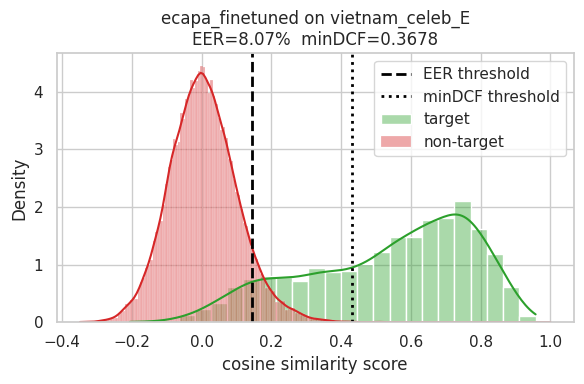


=== Evaluating 'ecapa_finetuned' on 'vietnam_celeb_H' ===
[read_trials] WARNING: dropping 3969/55016 pairs referencing 185 missing audio file(s) under /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00014.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00020.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00016.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00009.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00013.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-dataset/data/id00899/00005.wav
   missing file: /kaggle/input/datasets/davidthomastran/vietnam-celeb-dataset/full-da

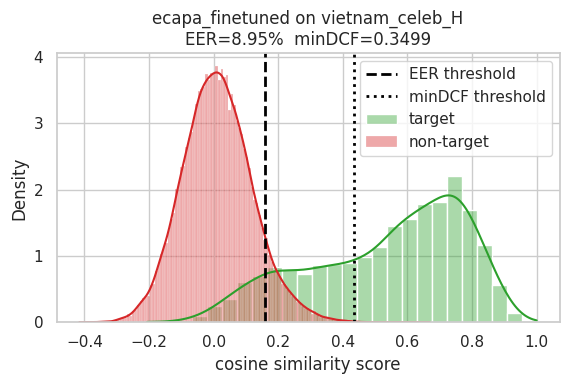

In [10]:
finetuned_model = load_finetuned_model()
print("Fine-tuned ECAPA-TDNN loaded on", DEVICE)

finetuned_cache = {}

result_celeb_e_ft, finetuned_cache = evaluate_model(
    finetuned_model, "ecapa_finetuned", "vietnam_celeb_E",
    CELEB_E_PAIR, CELEB_FULL_AUDIO, delimiter="\t",
    embed_cache=finetuned_cache,
)

result_celeb_h_ft, finetuned_cache = evaluate_model(
    finetuned_model, "ecapa_finetuned", "vietnam_celeb_H",
    CELEB_H_PAIR, CELEB_FULL_AUDIO, delimiter="\t",
    embed_cache=finetuned_cache,
)


## Comparison table

Both pretrained and fine-tuned results (written by `evaluate_model`) live in
`verification_results.csv`, so re-running this cell after both evaluation sections shows them side by side.

In [11]:
results_df = pd.read_csv(RESULTS_CSV)
pivot_eer = results_df.pivot(index="dataset", columns="model", values="eer_pct")
pivot_dcf = results_df.pivot(index="dataset", columns="model", values="min_dcf")

print("EER (%)")
display(pivot_eer.round(2))
print("\nminDCF (p_target=0.01)")
display(pivot_dcf.round(4))

results_df


EER (%)


model,ecapa_finetuned,ecapa_pretrained
dataset,,
vietnam_celeb_E,8.07,16.15
vietnam_celeb_H,8.95,19.16



minDCF (p_target=0.01)


model,ecapa_finetuned,ecapa_pretrained
dataset,,
vietnam_celeb_E,0.3678,0.5779
vietnam_celeb_H,0.3499,0.5734


,model,dataset,num_trials,num_genuine,num_impostor,eer_pct,min_dcf,scores_file
0,ecapa_pretrained,vietnam_celeb_E,47484,3965,43519,16.145252,0.577906,/kaggle/working/results/scores_ecapa_pretraine...
1,ecapa_pretrained,vietnam_celeb_H,51047,3978,47069,19.157231,0.573389,/kaggle/working/results/scores_ecapa_pretraine...
2,ecapa_finetuned,vietnam_celeb_E,47484,3965,43519,8.066881,0.367833,/kaggle/working/results/scores_ecapa_finetuned...
3,ecapa_finetuned,vietnam_celeb_H,51047,3978,47069,8.945706,0.349892,/kaggle/working/results/scores_ecapa_finetuned...
